## Downloading dataset using kaggle-cli

In [1]:
#!/bin/bash
!kaggle datasets download -d mohansacharya/graduate-admissions 

Dataset URL: https://www.kaggle.com/datasets/mohansacharya/graduate-admissions
License(s): CC0-1.0
100%|██████████████████████████████████████| 9.64k/9.64k [00:00<00:00, 21.4MB/s]



In [2]:
!pwd

/home/midori/Desktop/Nural_Network/Notebook/ANN/Graduate_Admission


In [ ]:
from zipfile import ZipFile
from pathlib import Path

zip_path = Path.home() / "/home/midori/Desktop/Nural_Network/Notebook/ANN/Graduate_Admission/graduate-admissions.zip"
extract_path = Path.home() / "Desktop/Nural_Network/Data/graduate_dataset"

In [18]:
with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print(f"Dataset Extracted ---> {extract_path}")

Dataset Extracted ---> /home/midori/Desktop/Nural_Network/Data


## Imports

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [53]:
from sklearn.model_selection import train_test_split

In [97]:
df = pd.read_csv('../../../Data/graduate_dataset/Admission_Predict_Ver1.1.csv')
df.head()

# SOP -> STATEMENT OF PURPOSE
# if index_col = 0, then the first column will be used as index and not considered as data.
# if index_col = None, then the first column will be considered as data 
# and a new index will be created for the dataframe.

,Serial_No,GRE Score,TOEFL Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


## Understand Dataset

In [48]:
df.shape

(500, 9)

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [24]:
df.duplicated().sum()

np.int64(0)

## Preprocessing

In [98]:
df.drop(columns=['Serial_No'], inplace=True)
df.head()
 
 # so if we want to drop the first column, we can use index_col = 0 and it will be dropped and used as index.
 # if we use index_col = 0 and no need to drop the first column

,GRE Score,TOEFL Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [99]:
X = df.drop(columns=['Chance_of_Admit'])
X

# X = df.iloc[:, 0:-1]
# Y = df.iloc[:,-1]

,GRE Score,TOEFL Score,University_Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,1
496,337,117,5,5.0,5.0,9.87,1
497,330,120,5,4.5,5.0,9.56,1
498,312,103,4,4.0,5.0,8.43,0


In [51]:
X.shape

(500, 7)

In [100]:
Y = df['Chance_of_Admit']
Y

0      0.92
1      0.76
2      0.72
3      0.80
4      0.65
       ... 
495    0.87
496    0.96
497    0.93
498    0.73
499    0.84
Name: Chance_of_Admit, Length: 500, dtype: float64

In [101]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,
                                                 test_size=0.2,
                                                 random_state=13)

## min-max normalization

In [55]:
# here we will use min-max normalization instead of StandardScaler because the upper and lower bound of the data is known.

In [56]:
from sklearn.preprocessing import MinMaxScaler

In [102]:
scaler = MinMaxScaler()

# we dont have to explicitly specify the bounds because min-max scaler will automatically scale the data to the 
# range of [0, 1] based on the minimum and maximum values of each feature in the training data.

In [103]:
X_train_Scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.transform(X_test)

In [59]:
X_train_Scaled

array([[0.1       , 0.25      , 0.25      , ..., 0.42857143, 0.16544118,
        0.        ],
       [0.76      , 0.71428571, 0.75      , ..., 0.85714286, 0.69852941,
        1.        ],
       [0.2       , 0.32142857, 0.5       , ..., 0.28571429, 0.25      ,
        0.        ],
       ...,
       [0.48      , 0.5       , 0.5       , ..., 1.        , 0.625     ,
        0.        ],
       [0.78      , 0.96428571, 0.75      , ..., 0.85714286, 0.72058824,
        1.        ],
       [0.66      , 0.57142857, 1.        , ..., 0.71428571, 0.56617647,
        1.        ]], shape=(400, 7))

## ANN-regression

In [62]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Input

In [104]:
model = Sequential([
    Input(shape=(7,)),
    Dense(7, activation='relu'),
    Dense(5, activation='relu'),
    Dense(1, activation='linear')
])

In [105]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102 (408.00 B)

 Trainable params: 102 (408.00 B)

 Non-trainable params: 0 (0.00 B)

In [106]:
model.compile(loss='mean_squared_error',
              optimizer='adam',
              metrics=['accuracy'])

In [113]:
history = model.fit(X_train_Scaled, Y_train, 
                    epochs=40, 
                    validation_split=0.2)

Epoch 1/40


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: 0.0053 - val_accuracy: 0.0000e+00 - val_loss: 0.0059
Epoch 2/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 0.0053 - val_accuracy: 0.0000e+00 - val_loss: 0.0058
Epoch 3/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 0.0053 - val_accuracy: 0.0000e+00 - val_loss: 0.0058
Epoch 4/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 0.0052 - val_accuracy: 0.0000e+00 - val_loss: 0.0058
Epoch 5/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 0.0052 - val_accuracy: 0.0000e+00 - val_loss: 0.0058
Epoch 6/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: 0.0052 - val_accuracy: 0.0000e+00 - val_loss: 0.0057
Epoch 7/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 0.0052 - val_accuracy: 0.0000e+00 - val_loss: 0.0056
Epoch 8/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 

In [114]:
model.save('graduate_admission_model.keras')

## prediction

In [115]:
Y_pred = model.predict(X_test_Scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [110]:
from sklearn.metrics import r2_score

In [116]:
r2_score(Y_test, Y_pred)

0.7825846524763385

## Graph

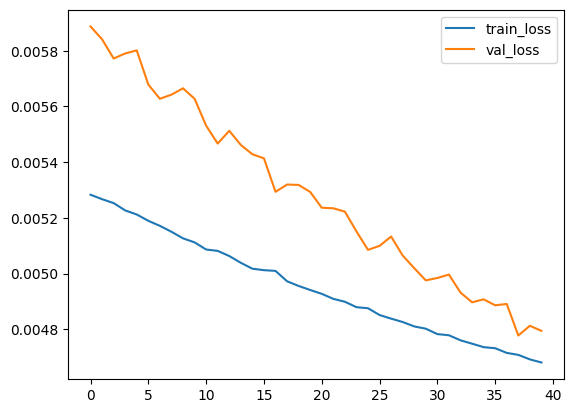

In [117]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

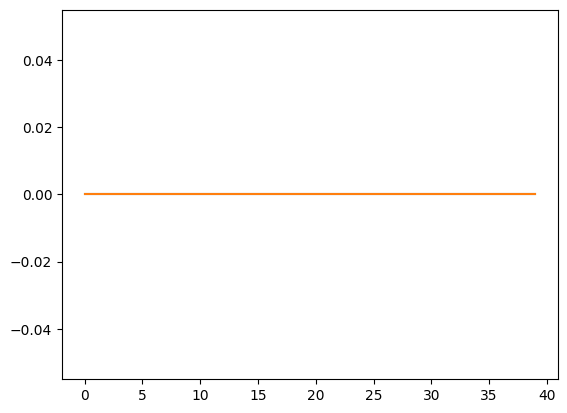

In [120]:
plt.plot(history.history['accuracy'], label='train_loss')
plt.plot(history.history['val_accuracy'], label='val_loss')